In [1]:
import math
import numpy as np
import statsmodels.stats.power as smp
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd


plt.style.use('ggplot')

### Бутстреп

Пусть мы хотим оценить 90% квантиль. Мы можем это сделать по данным, но как оценить стандартное отклонение полученной оценки? Простой универсальной теоретической формулы для оценки стандартного отклонения квантиля нет.

Было бы хорошо, если у нас было 100 параллельных вселенных. Мы бы в каждой вселенной собрали данные, посчитали 100 квантилей и оценили стандартное отклонения по полученным значениям. Но у нас нет 100 параллельных вселенных.



Используем бутстрап.
Для этого 1000 раз сгенерируем подвыборки из ЭФР, вычислим значение статистики в каждой подвыборке и оценим стандартное отклонение получившихся значений.

In [3]:
n = 1000            # размер исходной выборки
B = 1000            # количество генерируемых подвыборок

values = np.random.normal(90, 20, n)
quantile = np.quantile(values, 0.9)
bootstrap_quantiles = []
for _ in range(B):
    # берем выборку того же размера с возвращением
    bootstrap_values = np.random.choice(values, n, replace=True)
    # считаем квантиль для бутстрап-выборки
    bootstrap_quantiles.append(np.quantile(bootstrap_values, 0.9))
std = np.std(bootstrap_quantiles)
print(f'Оценка 90% квантиля: {quantile:0.2f}')
print(f'Оценка std для 90% квантиля: {std:0.2f}')

Оценка 90% квантиля: 116.40
Оценка std для 90% квантиля: 1.07


### Обратим внимание на два момента:

1) Чтобы оценка стандартного отклонения была несмещённой, **необходимо генерировать выборки такого же размера**, как и размер исходной выборки;

2) **Количество итераций бутстрепа** рекомендуется брать в диапазоне **от 1000 до 10000**. Этого, как правило, хватает для получения достаточно точных результатов.

### ДИ с помощью бутстрепа

1. Нормальный ДИ (**pe - point estimation, точечная оценка по выборке**). Его часто строят, когда исходное распределение плюс-минус похоже на нормальное (не супер скошенное).  
Если посмотреть на формулу, видно, что она такая же, как для обычного нормального доверительного интервала, только оценки среднего и станлартного отклонения берутся из бутстрап-распределения

$\left[ \widehat{pe} - z_{1-\alpha/2} \cdot \widehat{std}, \;\; \widehat{pe} + z_{1-\alpha/2} \cdot \widehat{std} \right]$

2. Персентильный бутстреп (отсекаем просто по квантилям хвосты) - напрямую по квантилям бутстрап-распределения. Чаще всего используют этот вариант

$\left[ \widehat{q}_{\alpha/2}, \;\; \widehat{q}_{1-\alpha/2} \right]$


3. Центральный ДИ

$\left[ 2 \cdot \widehat{pe} - \widehat{q}_{1-\alpha/2}, \;\; 2 \cdot \widehat{pe} - \widehat{q}_{\alpha/2} \right]
$

Центральный ДИ для логнормального распределения смещён в сторону с нулевой плотностью (тут была картинка). Это можно интерпретировать как стремление перестраховаться на случай, если у нас неполная информация о распределении, и левее нуля на самом деле могут быть значения.



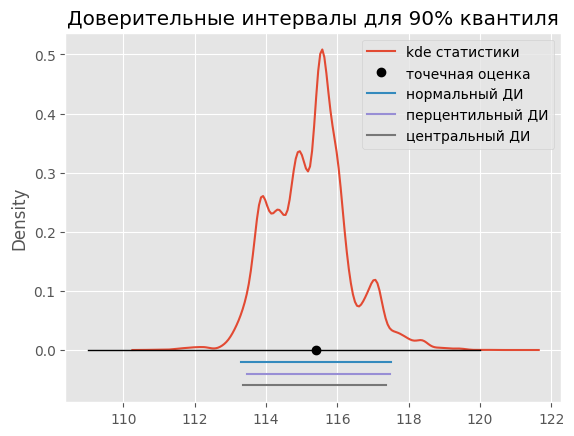

In [6]:
import seaborn as sns

def get_normal_ci(bootstrap_stats, pe, alpha):
    """
    Строит нормальный доверительный интервал.
    bootstrap_stats - значения статистики из бутстрап-выборок
    pe - точечная оценка статистики из исходной выборки
    """
    z = stats.norm.ppf(1 - alpha / 2)
    se = np.std(bootstrap_stats)
    left, right = pe - z * se, pe + z * se
    return left, right

def get_percentile_ci(bootstrap_stats, pe, alpha):
    """
    Строит перцентильный доверительный интервал.
    """
    left, right = np.quantile(bootstrap_stats, [alpha / 2, 1 - alpha / 2])
    return left, right

def get_pivotal_ci(bootstrap_stats, pe, alpha):
    """
    Строит центральный доверительный интервал.
    """
    left, right= 2 * pe - np.quantile(bootstrap_stats, [1 - alpha / 2,  alpha / 2])
    return left, right

n = 1000
B = 10000
alpha = 0.05

values = np.random.normal(90, 20, n)
quantile = np.quantile(values, 0.9)
bootstrap_quantiles = np.quantile(np.random.choice(values, (B, n), True), 0.9, axis=1)

normal_ci = get_normal_ci(bootstrap_quantiles, quantile, alpha)
percentile_ci = get_percentile_ci(bootstrap_quantiles, quantile, alpha)
pivotal_ci = get_pivotal_ci(bootstrap_quantiles, quantile, alpha)

sns.kdeplot(bootstrap_quantiles, label='kde статистики')
plt.plot([quantile], [0], 'o', c='k', markersize=6, label='точечная оценка')
plt.plot([109, 120], [0, 0], 'k', linewidth=1)
d = 0.02
plt.plot(normal_ci, [-d, -d], label='нормальный ДИ')
plt.plot(percentile_ci, [-d*2, -d*2], label='перцентильный ДИ')
plt.plot(pivotal_ci, [-d*3, -d*3], label='центральный ДИ')

plt.title('Доверительные интервалы для 90% квантиля')
plt.legend()
plt.show()

Тут видно, что 3 вида ДИ дают на самом деле похожие результаты

## Проверка гипотез с помощью бутстрепа

Чтобы проверить гипотезу о равенстве квантилей на уровне значимости 5% достаточно **построить 95% доверительный интервал для разности квантилей между группами**.

**Если ноль находится вне доверительного интервала, то отличия статистически значимы, иначе нет.**

### Алгоритм проверки гипотез о равенстве двух произвольных метрик с помощью бутстрепа

Опишем ещё раз алгоритм проверки гипотез о равенстве двух произвольных метрик с помощью бутстрепа:

1. Генерируем пару подвыборок того же размера из исходных данных контрольной и экспериментальной групп;

2. Считаем метрики (реализация оценки метрики) для каждой из групп;

3. Вычисляем разность метрик, сохраняем полученное значение;

4. Повторяем шаги 1-3 от 1000 до 10000 раз;

5. Строим доверительный интервал с уровнем значимости $\alpha$;

6. Если 0 не принадлежит ДИ, то отличия статистически значимы на уровне значимости $\alpha$, иначе нет.

In [13]:
n = 1000
B = 10000
alpha = 0.05

# берем выборки из нормального распределения
values_a = np.random.normal(90, 20, n) # среднее 90, дисперсия 20
values_b = np.random.normal(90, 15, n) # среднее 90, дисперсия 15

# точечная оценка разности квантилей
pe = np.quantile(values_b, 0.9) - np.quantile(values_a, 0.9)

# бутстрапируем
bootstrap_values_a = np.random.choice(values_a, (B, n), True)       # сгенерируем n примеров размера B (матрицу Bxn).
bootstrap_metrics_a = np.quantile(bootstrap_values_a, 0.9, axis=1)  # посчитаем квантиль. Получим n квантилей

bootstrap_values_b = np.random.choice(values_b, (B, n), True)
bootstrap_metrics_b = np.quantile(bootstrap_values_b, 0.9, axis=1)

# считаем разницу квантилей по бутстрап-выборкам
bootstrap_stats = bootstrap_metrics_b - bootstrap_metrics_a

# доверительный интервал для разницы квантилей
ci = get_percentile_ci(bootstrap_stats, pe, alpha)

# проверяем, лежит ли 0 в ДИ
has_effect = not (ci[0] < 0 < ci[1])

# выводим результаты
print(f'Значение 90% квантиля изменилось на: {pe:0.2f}')
print(f'{((1 - alpha) * 100)}% доверительный интервал: ({ci[0]:0.2f}, {ci[1]:0.2f})')
print(f'Отличия статистически значимые: {has_effect}')

Значение 90% квантиля изменилось на: -6.56
95.0% доверительный интервал: (-8.91, -4.46)
Отличия статистически значимые: True


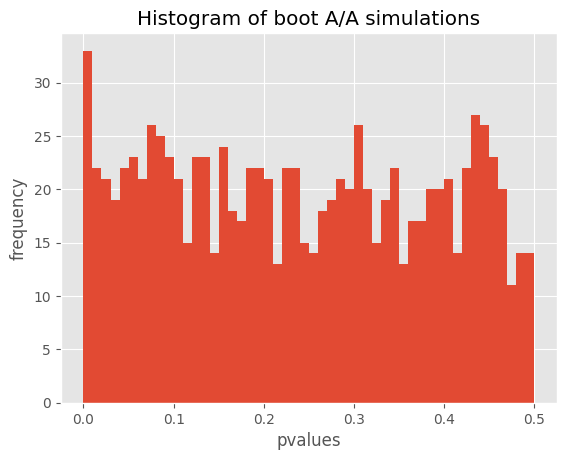

In [16]:
import numpy as np

n = 1000
simulations = 100
simulations_b = 1000
n_s = 1000
statistic = np.mean
bootstrap_conf_level = 0.05

res = []
for _ in range(1000):
    s1 = np.random.exponential(scale=1/0.001, size=n)
    s2 = np.random.exponential(scale=1/0.001, size=n)
    s1_idx = np.random.randint(0, n, size=(1000, n))
    s2_idx = np.random.randint(0, n, size=(1000, n))
    boot_data = np.mean(s1[s1_idx], axis=1) - np.mean(s2[s2_idx], axis=1)

    p_value = min(
        (0 > boot_data).sum() / len(boot_data),
        1 - (0 > boot_data).sum() / len(boot_data)
    )
    res.append(p_value)

plt.hist(res, bins=50)
plt.style.use('ggplot')
plt.xlabel('pvalues')
plt.ylabel('frequency')
plt.title('Histogram of boot A/A simulations')
plt.show()
